# 03  Baseline Scheduling Algorithms
---

## What this notebook does

This notebook implements and evaluates two **baseline scheduling algorithms** that serve
as the comparison benchmarks for the RL agent in Chapter 5.

A baseline must be:
- Simple enough to implement without machine learning
- Representative of current best-practice scheduling approaches
- Evaluated on the **same 200 test scenarios** as the RL agent

### The two baselines

| Baseline | Strategy | Represents |
|---|---|---|
| **FIFO** | Execute tasks in the order they arrive | Weakest possible scheduler — no intelligence |
| **Priority Queue** | Sort by weighted deadline + priority score | Current best-practice (Todoist, Asana, etc.) |

### Three evaluation metrics (same as RL agent)
| Metric | Abbreviation | Definition |
|---|---|---|
| Task Completion Rate | TCR | % of tasks completed before their deadline |
| Deadline Deviation | DD | Mean absolute time difference from deadline (minutes) |
| Schedule Recovery Time | SRT | Time to produce valid schedule after disruption (minutes) |

### Notebook structure
1. Imports and configuration
2. Load test dataset
3. Simulation environment
4. Baseline 1 — FIFO scheduler
5. Baseline 2 — Priority queue scheduler
6. Disruption handling
7. Evaluation on 200 test scenarios
8. Results and visualisation
9. Results summary


## 1. Imports and Configuration

In [1]:
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ─────────────────────────────────────────────────────────────
WORKDAY_MINUTES  = 600      # 08:00 to 18:00
TEST_DATA_PATH   = "data/test_scenarios.json"
RESULTS_PATH     = "data/baseline_results.csv"
OUTPUT_FIG_PATH  = "data/fig7_baseline_results.png"

# Priority queue weight — how much deadline urgency vs priority score matters
# 0.7 deadline + 0.3 priority matches industry tools like Todoist
DEADLINE_WEIGHT  = 0.7
PRIORITY_WEIGHT  = 0.3

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})
PALETTE = ["#1D9E75", "#534AB7", "#BA7517", "#2E75B6", "#D85A30"]

print("Imports loaded.")
print(f"Workday duration : {WORKDAY_MINUTES} minutes")
print(f"Deadline weight  : {DEADLINE_WEIGHT}")
print(f"Priority weight  : {PRIORITY_WEIGHT}")


Imports loaded.
Workday duration : 600 minutes
Deadline weight  : 0.7
Priority weight  : 0.3


## 2. Load Test Dataset

We load the **200 held-out test scenarios** that were locked away during dataset
generation. These are the same 200 scenarios the RL agent will be evaluated on
in Chapter 5, ensuring a fair comparison.

> ⚠️ This is the **only notebook** that should load `test_scenarios.json`.
> The training notebook (05_DQN_Training) uses `train_scenarios.json` only.


In [2]:
with open(TEST_DATA_PATH) as f:
    test_scenarios = json.load(f)

print(f"Test scenarios loaded : {len(test_scenarios)}")
print()

# Quick summary
complexities = [s['complexity'] for s in test_scenarios]
print("Complexity breakdown:")
for c in ['low', 'medium', 'high']:
    n = complexities.count(c)
    print(f"  {c:<8} {n:>3} scenarios ({n/len(test_scenarios)*100:.1f}%)")

print()
print("Sample scenario:")
s = test_scenarios[0]
print(f"  ID         : {s['scenario_id']}")
print(f"  Complexity : {s['complexity']}")
print(f"  Tasks      : {s['n_tasks']}")
print(f"  Disruptions: {s['n_disruptions']}")
print(f"  Feasible   : {s['feasible']}")


Test scenarios loaded : 200

Complexity breakdown:
  low       68 scenarios (34.0%)
  medium    75 scenarios (37.5%)
  high      57 scenarios (28.5%)

Sample scenario:
  ID         : SCN_0689
  Complexity : medium
  Tasks      : 11
  Disruptions: 3
  Feasible   : False


## 3. Simulation Environment

Before implementing the schedulers, we define the simulation environment that
both baselines (and later the RL agent) operate within.

The environment:
- Simulates a 600-minute working day
- Executes tasks one at a time in the order provided by the scheduler
- Applies disruption events at the correct time points
- Records which tasks were completed on time, late, or not at all

### Key simulation rules
- Tasks are executed sequentially — only one task runs at a time
- A task is **on time** if it completes before its `deadline_min`
- A task is **missed** if there is no time left to start it
- Disruptions are applied when `current_time >= disruption.arrival_min`


In [3]:
def apply_disruptions(task_queue, disruptions, current_time):
    """
    Apply any disruptions whose arrival time has passed.
    Returns updated task queue and list of applied disruptions.
    """
    applied   = []
    remaining = []

    for d in disruptions:
        if d['type'] == 'urgent_insertion':
            if current_time >= d.get('arrival_min', 0):
                task_queue.append(copy.deepcopy(d['task']))
                applied.append(d)
            else:
                remaining.append(d)

        elif d['type'] == 'deadline_shift':
            # Apply immediately — deadline changes happen as soon as notified
            for task in task_queue:
                if task['id'] == d['target_task_id']:
                    task['deadline_min'] = d['new_deadline_min']
            applied.append(d)

        elif d['type'] == 'task_cancellation':
            task_queue = [t for t in task_queue
                          if t['id'] != d.get('target_task_id')]
            applied.append(d)

        else:
            remaining.append(d)

    return task_queue, remaining


def simulate_schedule(ordered_tasks, disruptions, scheduler_fn=None):
    """
    Simulate executing tasks in the given order.

    Parameters:
        ordered_tasks : list of task dicts in execution order
        disruptions   : list of disruption events
        scheduler_fn  : optional function to re-order queue after disruption
                        if None, order stays fixed after disruption (FIFO style)

    Returns:
        results dict with TCR, DD, SRT, and per-task outcomes
    """
    current_time    = 0
    completed       = []
    missed          = []
    task_queue      = copy.deepcopy(ordered_tasks)
    pending_disrupt = copy.deepcopy(disruptions)
    srt_times       = []

    while task_queue and current_time < WORKDAY_MINUTES:

        # Apply any disruptions before picking next task
        pre_len        = len(task_queue)
        task_queue, pending_disrupt = apply_disruptions(
            task_queue, pending_disrupt, current_time
        )

        # If disruption changed the queue and we have a re-scheduler, time it
        if len(task_queue) != pre_len and scheduler_fn is not None:
            t0         = time.perf_counter()
            task_queue = scheduler_fn(task_queue, current_time)
            srt        = (time.perf_counter() - t0) * 60000  # convert to ms → minutes
            srt_times.append(max(srt, 0.001))   # floor at 1ms

        # Pick next task from front of queue
        task = task_queue.pop(0)

        # Check dependencies are satisfied
        completed_ids = {t['id'] for t in completed}
        if task.get('dependencies'):
            unmet = [d for d in task['dependencies'] if d not in completed_ids]
            if unmet:
                # Push to back of queue and continue
                task_queue.append(task)
                current_time += 1
                continue

        # Can we finish the task before the workday ends?
        finish_time = current_time + task['duration_min']
        if finish_time > WORKDAY_MINUTES:
            missed.append({**task, 'finish_time': None, 'on_time': False,
                           'deadline_deviation': None})
            continue

        # Execute task
        current_time = finish_time
        on_time      = current_time <= task['deadline_min']
        deviation    = abs(current_time - task['deadline_min'])

        completed.append({
            **task,
            'finish_time':        current_time,
            'on_time':            on_time,
            'deadline_deviation': deviation,
        })

    # Tasks still in queue at end of day are missed
    for task in task_queue:
        missed.append({**task, 'finish_time': None, 'on_time': False,
                       'deadline_deviation': None})

    # Compute metrics
    total     = len(completed) + len(missed)
    tcr       = len([t for t in completed if t['on_time']]) / total if total > 0 else 0
    deviations= [t['deadline_deviation'] for t in completed if t['deadline_deviation'] is not None]
    dd        = np.mean(deviations) if deviations else WORKDAY_MINUTES
    srt       = np.mean(srt_times)  if srt_times  else 0.0

    return {
        'tcr':       tcr,
        'dd':        dd,
        'srt':       srt,
        'completed': len(completed),
        'missed':    len(missed),
        'total':     total,
        'on_time':   len([t for t in completed if t['on_time']]),
    }


print("Simulation environment defined.")
print("Functions: apply_disruptions(), simulate_schedule()")


Simulation environment defined.
Functions: apply_disruptions(), simulate_schedule()


## 4. Baseline 1 — FIFO Scheduler

**First In, First Out (FIFO)** is the simplest possible scheduling strategy.
Tasks are executed in the exact order they appear in the scenario — no sorting,
no re-ordering, no intelligence.

### Why include FIFO?
FIFO represents the absolute lower bound of scheduling performance. Any
intelligent scheduler should beat FIFO. If the RL agent cannot outperform
FIFO, there is a serious problem with the agent design.

### FIFO behaviour under disruptions
When a disruption occurs (e.g. an urgent task is inserted), FIFO appends
it to the **end** of the queue. This is its biggest weakness — a critical
urgent task may arrive but wait behind ten lower-priority tasks.


In [4]:
def fifo_schedule(tasks, current_time=0):
    """
    FIFO scheduler — return tasks in their original order.
    Ignores deadline, priority, and current time completely.
    On disruption (urgent insertion), new task goes to end of queue.
    """
    return list(tasks)   # no sorting — original order preserved


def run_fifo(scenario):
    """Run FIFO on a single scenario and return metrics."""
    tasks       = copy.deepcopy(scenario['tasks'])
    disruptions = copy.deepcopy(scenario['disruptions'])
    ordered     = fifo_schedule(tasks)
    return simulate_schedule(ordered, disruptions, scheduler_fn=None)


# ── Test on one scenario ──────────────────────────────────────────────────────
sample     = test_scenarios[0]
fifo_result= run_fifo(sample)

print("FIFO test on one scenario:")
print(f"  Scenario     : {sample['scenario_id']} ({sample['complexity']} complexity)")
print(f"  Total tasks  : {fifo_result['total']}")
print(f"  On time      : {fifo_result['on_time']}")
print(f"  Missed       : {fifo_result['missed']}")
print(f"  TCR          : {fifo_result['tcr']*100:.1f}%")
print(f"  Deadline dev : {fifo_result['dd']:.1f} min")
print(f"  Recovery time: {fifo_result['srt']:.4f} min")


FIFO test on one scenario:
  Scenario     : SCN_0689 (medium complexity)
  Total tasks  : 13
  On time      : 4
  Missed       : 5
  TCR          : 30.8%
  Deadline dev : 157.8 min
  Recovery time: 0.0000 min


## 5. Baseline 2 — Static Priority Queue Scheduler

The **priority queue** scheduler sorts tasks by a weighted score combining
deadline urgency and priority level. This represents the current best-practice
approach used by tools like Todoist, Asana, and Monday.com.

### Scoring formula
```
urgency_score = 1 - (deadline_min / WORKDAY_MINUTES)   # higher = more urgent
priority_norm = (priority - 1) / 4                      # normalise 1-5 to 0-1
score = (DEADLINE_WEIGHT × urgency_score) + (PRIORITY_WEIGHT × priority_norm)
```

Tasks with higher scores are executed first. The weights (0.7 deadline,
0.3 priority) reflect the industry standard of treating deadline proximity
as more important than subjective priority ratings.

### Static vs dynamic
The key limitation of this baseline is that it is **static** — tasks are
sorted once at the start of the day. When a disruption occurs, the scheduler
re-sorts the remaining queue using the same formula, but it does not learn
from past disruptions or adapt its strategy over time. This is exactly the
limitation the RL agent is designed to overcome.


In [5]:
def priority_queue_score(task, current_time=0):
    """
    Compute scheduling priority score for a task.
    Higher score = execute sooner.
    """
    # Urgency: how close is the deadline relative to remaining workday
    remaining_workday = max(WORKDAY_MINUTES - current_time, 1)
    time_to_deadline  = max(task['deadline_min'] - current_time, 0)
    urgency_score     = 1.0 - (time_to_deadline / remaining_workday)

    # Priority: normalise 1-5 to 0-1
    priority_norm = (task['priority'] - 1) / 4.0

    return (DEADLINE_WEIGHT * urgency_score) + (PRIORITY_WEIGHT * priority_norm)


def priority_queue_schedule(tasks, current_time=0):
    """
    Priority queue scheduler — sort tasks by weighted score.
    Called once at start, and again after each disruption.
    """
    return sorted(tasks,
                  key=lambda t: priority_queue_score(t, current_time),
                  reverse=True)   # highest score first


def run_priority_queue(scenario):
    """Run priority queue scheduler on a single scenario."""
    tasks       = copy.deepcopy(scenario['tasks'])
    disruptions = copy.deepcopy(scenario['disruptions'])
    ordered     = priority_queue_schedule(tasks, current_time=0)
    return simulate_schedule(ordered, disruptions,
                             scheduler_fn=priority_queue_schedule)


# ── Test on one scenario ──────────────────────────────────────────────────────
pq_result = run_priority_queue(sample)

print("Priority Queue test on one scenario:")
print(f"  Scenario     : {sample['scenario_id']} ({sample['complexity']} complexity)")
print(f"  Total tasks  : {pq_result['total']}")
print(f"  On time      : {pq_result['on_time']}")
print(f"  Missed       : {pq_result['missed']}")
print(f"  TCR          : {pq_result['tcr']*100:.1f}%")
print(f"  Deadline dev : {pq_result['dd']:.1f} min")
print(f"  Recovery time: {pq_result['srt']:.4f} min")

print()
print("Comparison on this scenario:")
print(f"  {'Metric':<20} {'FIFO':>10} {'Priority Q':>12}")
print(f"  {'TCR':<20} {fifo_result['tcr']*100:>9.1f}% {pq_result['tcr']*100:>11.1f}%")
print(f"  {'Deadline Dev (min)':<20} {fifo_result['dd']:>10.1f} {pq_result['dd']:>12.1f}")


Priority Queue test on one scenario:
  Scenario     : SCN_0689 (medium complexity)
  Total tasks  : 13
  On time      : 2
  Missed       : 7
  TCR          : 15.4%
  Deadline dev : 163.0 min
  Recovery time: 0.4217 min

Comparison on this scenario:
  Metric                     FIFO   Priority Q
  TCR                       30.8%        15.4%
  Deadline Dev (min)        157.8        163.0


## 6. Disruption Handling Demonstration

This cell demonstrates how each baseline handles the three disruption types.
This is important for understanding the SRT (Schedule Recovery Time) metric —
how long does it take each scheduler to produce a valid schedule after a disruption?


In [6]:
# Find scenarios with each disruption type for demonstration
def find_scenario_with_disruption(dtype):
    for s in test_scenarios:
        for d in s['disruptions']:
            if d['type'] == dtype:
                return s, d
    return None, None

print("Disruption handling demonstration")
print("=" * 55)

for dtype in ['urgent_insertion', 'deadline_shift', 'task_cancellation']:
    scenario, disruption = find_scenario_with_disruption(dtype)
    if scenario:
        fifo_r = run_fifo(scenario)
        pq_r   = run_priority_queue(scenario)
        print(f"\nDisruption type : {dtype}")
        print(f"Scenario        : {scenario['scenario_id']}")
        print(f"  FIFO  — TCR: {fifo_r['tcr']*100:.1f}%  DD: {fifo_r['dd']:.1f} min")
        print(f"  PQ    — TCR: {pq_r['tcr']*100:.1f}%  DD: {pq_r['dd']:.1f} min")


Disruption handling demonstration

Disruption type : urgent_insertion
Scenario        : SCN_0689
  FIFO  — TCR: 30.8%  DD: 157.8 min
  PQ    — TCR: 15.4%  DD: 163.0 min

Disruption type : deadline_shift
Scenario        : SCN_0689
  FIFO  — TCR: 30.8%  DD: 157.8 min
  PQ    — TCR: 15.4%  DD: 163.0 min

Disruption type : task_cancellation
Scenario        : SCN_0449
  FIFO  — TCR: 57.1%  DD: 242.2 min
  PQ    — TCR: 57.1%  DD: 208.3 min


## 7. Full Evaluation on 200 Test Scenarios

Both baselines are now evaluated across all 200 held-out test scenarios.
This produces the benchmark numbers that the RL agent will be compared against
in Chapter 5.


In [7]:
print("Running full evaluation on 200 test scenarios...")
print("This should take less than 30 seconds.")
print()

fifo_results = []
pq_results   = []

for i, scenario in enumerate(test_scenarios):
    fifo_r = run_fifo(scenario)
    pq_r   = run_priority_queue(scenario)

    fifo_results.append({
        'scenario_id':  scenario['scenario_id'],
        'complexity':   scenario['complexity'],
        'n_tasks':      scenario['n_tasks'],
        'feasible':     scenario['feasible'],
        'scheduler':    'FIFO',
        'tcr':          fifo_r['tcr'],
        'dd':           fifo_r['dd'],
        'srt':          fifo_r['srt'],
        'completed':    fifo_r['completed'],
        'missed':       fifo_r['missed'],
        'on_time':      fifo_r['on_time'],
    })
    pq_results.append({
        'scenario_id':  scenario['scenario_id'],
        'complexity':   scenario['complexity'],
        'n_tasks':      scenario['n_tasks'],
        'feasible':     scenario['feasible'],
        'scheduler':    'Priority Queue',
        'tcr':          pq_r['tcr'],
        'dd':           pq_r['dd'],
        'srt':          pq_r['srt'],
        'completed':    pq_r['completed'],
        'missed':       pq_r['missed'],
        'on_time':      pq_r['on_time'],
    })

    if (i+1) % 50 == 0:
        print(f"  {i+1}/200 scenarios processed")

df_fifo = pd.DataFrame(fifo_results)
df_pq   = pd.DataFrame(pq_results)
df_all  = pd.concat([df_fifo, df_pq], ignore_index=True)

# Save results
df_all.to_csv(RESULTS_PATH, index=False)
print(f"\nResults saved to {RESULTS_PATH}")


Running full evaluation on 200 test scenarios...
This should take less than 30 seconds.

  50/200 scenarios processed
  100/200 scenarios processed
  150/200 scenarios processed
  200/200 scenarios processed

Results saved to data/baseline_results.csv


## 8. Results and Visualisation

In [8]:
# ── Aggregate metrics ─────────────────────────────────────────────────────────
def summarise(df):
    return {
        'TCR (%)':      df['tcr'].mean()  * 100,
        'DD (min)':     df['dd'].mean(),
        'SRT (min)':    df['srt'].mean(),
        'On-time tasks':df['on_time'].sum(),
        'Missed tasks': df['missed'].sum(),
    }

fifo_summary = summarise(df_fifo)
pq_summary   = summarise(df_pq)

print("=" * 60)
print(f"  {'Metric':<22} {'FIFO':>14} {'Priority Queue':>16}")
print("=" * 60)
for metric in fifo_summary:
    fv = fifo_summary[metric]
    pv = pq_summary[metric]
    if isinstance(fv, float):
        print(f"  {metric:<22} {fv:>14.2f} {pv:>16.2f}")
    else:
        print(f"  {metric:<22} {fv:>14} {pv:>16}")
print("=" * 60)


  Metric                           FIFO   Priority Queue
  TCR (%)                         38.49            37.79
  DD (min)                       116.42           120.75
  SRT (min)                        0.00             0.30
  On-time tasks                     729              714
  Missed tasks                      887              873


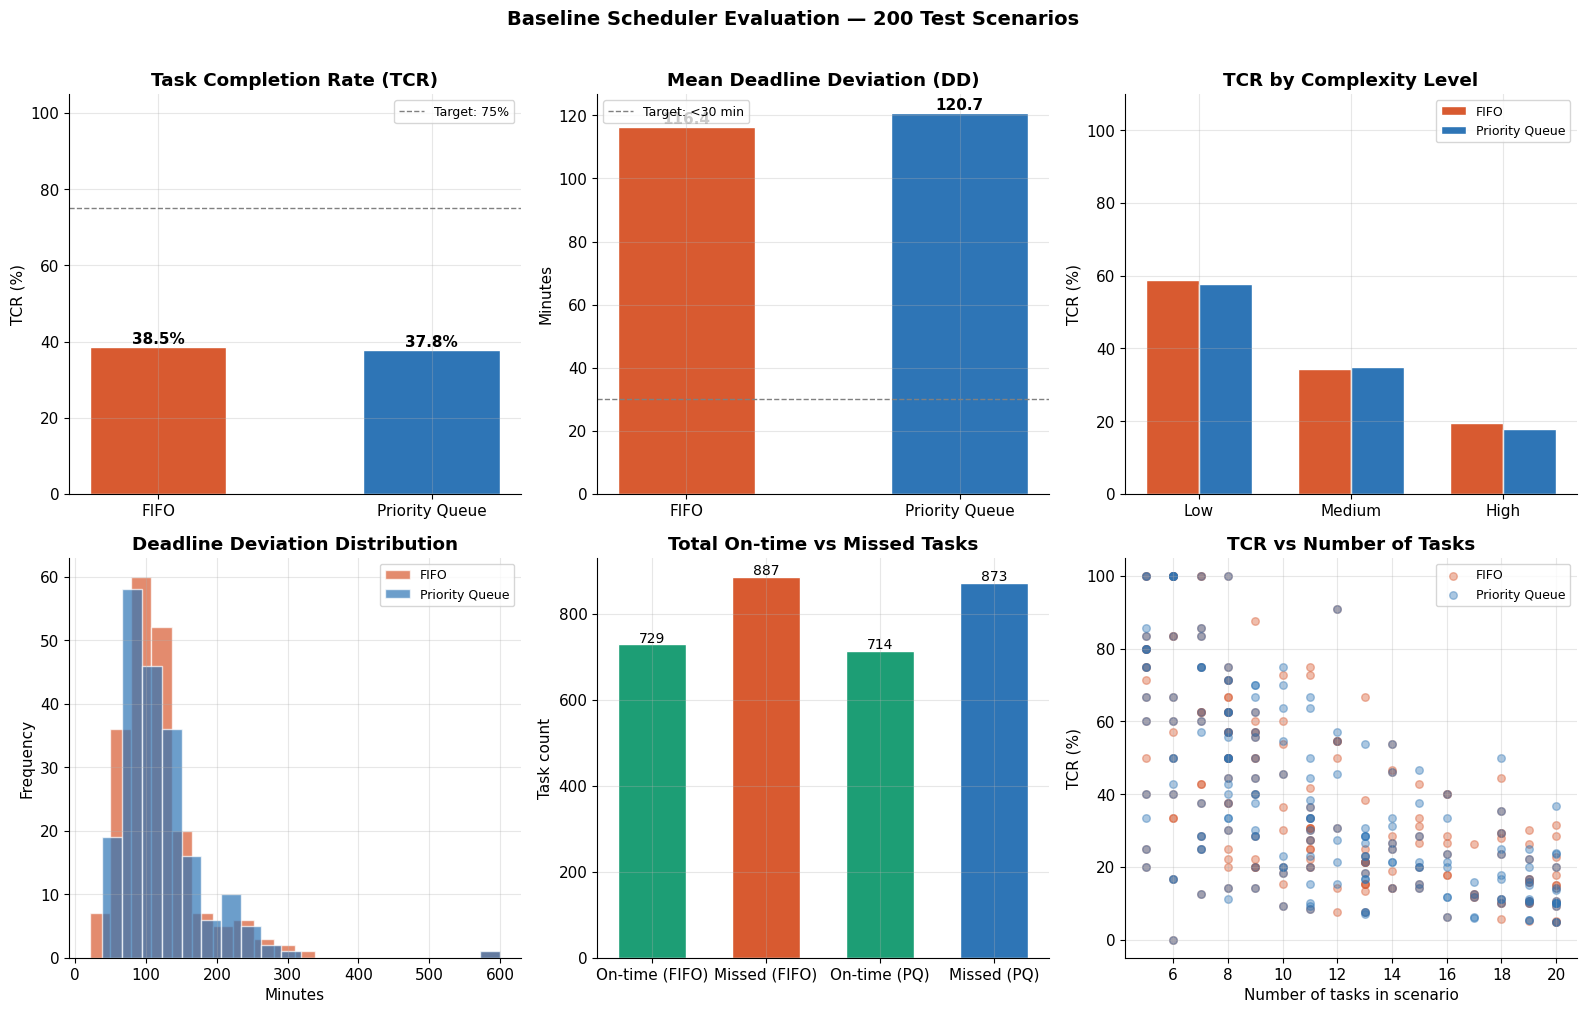

Figure saved: data/fig7_baseline_results.png


In [9]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Baseline Scheduler Evaluation — 200 Test Scenarios",
             fontsize=14, fontweight='bold', y=1.01)

schedulers = ['FIFO', 'Priority Queue']
colors     = [PALETTE[4], PALETTE[3]]

# ── Plot 1: TCR by scheduler ──────────────────────────────────────────────────
tcr_vals = [fifo_summary['TCR (%)'], pq_summary['TCR (%)']]
bars = axes[0,0].bar(schedulers, tcr_vals, color=colors, width=0.5, edgecolor='white')
axes[0,0].set_title("Task Completion Rate (TCR)", fontweight='bold')
axes[0,0].set_ylabel("TCR (%)")
axes[0,0].set_ylim(0, 105)
axes[0,0].axhline(75, color='gray', linestyle='--', linewidth=1, label='Target: 75%')
axes[0,0].legend(fontsize=9)
for bar, val in zip(bars, tcr_vals):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

# ── Plot 2: DD by scheduler ───────────────────────────────────────────────────
dd_vals = [fifo_summary['DD (min)'], pq_summary['DD (min)']]
bars = axes[0,1].bar(schedulers, dd_vals, color=colors, width=0.5, edgecolor='white')
axes[0,1].set_title("Mean Deadline Deviation (DD)", fontweight='bold')
axes[0,1].set_ylabel("Minutes")
axes[0,1].axhline(30, color='gray', linestyle='--', linewidth=1, label='Target: <30 min')
axes[0,1].legend(fontsize=9)
for bar, val in zip(bars, dd_vals):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f"{val:.1f}", ha='center', fontsize=11, fontweight='bold')

# ── Plot 3: TCR by complexity ─────────────────────────────────────────────────
x      = np.arange(3)
width  = 0.35
labels = ['Low', 'Medium', 'High']
fifo_tcr_c = [df_fifo[df_fifo['complexity']==c]['tcr'].mean()*100 for c in ['low','medium','high']]
pq_tcr_c   = [df_pq[df_pq['complexity']==c]['tcr'].mean()*100     for c in ['low','medium','high']]
axes[0,2].bar(x - width/2, fifo_tcr_c, width, label='FIFO',           color=PALETTE[4], edgecolor='white')
axes[0,2].bar(x + width/2, pq_tcr_c,   width, label='Priority Queue', color=PALETTE[3], edgecolor='white')
axes[0,2].set_title("TCR by Complexity Level", fontweight='bold')
axes[0,2].set_ylabel("TCR (%)")
axes[0,2].set_xticks(x)
axes[0,2].set_xticklabels(labels)
axes[0,2].set_ylim(0, 110)
axes[0,2].legend(fontsize=9)

# ── Plot 4: DD distribution ───────────────────────────────────────────────────
axes[1,0].hist(df_fifo['dd'], bins=20, alpha=0.7, color=PALETTE[4],
               label='FIFO', edgecolor='white')
axes[1,0].hist(df_pq['dd'],   bins=20, alpha=0.7, color=PALETTE[3],
               label='Priority Queue', edgecolor='white')
axes[1,0].set_title("Deadline Deviation Distribution", fontweight='bold')
axes[1,0].set_xlabel("Minutes")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend(fontsize=9)

# ── Plot 5: On-time vs missed tasks ──────────────────────────────────────────
categories = ['On-time (FIFO)', 'Missed (FIFO)', 'On-time (PQ)', 'Missed (PQ)']
values     = [fifo_summary['On-time tasks'], fifo_summary['Missed tasks'],
              pq_summary['On-time tasks'],   pq_summary['Missed tasks']]
bar_colors = [PALETTE[0], PALETTE[4], PALETTE[0], PALETTE[3]]
bars = axes[1,1].bar(categories, values, color=bar_colors, edgecolor='white', width=0.6)
axes[1,1].set_title("Total On-time vs Missed Tasks", fontweight='bold')
axes[1,1].set_ylabel("Task count")
for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   str(int(val)), ha='center', fontsize=10)

# ── Plot 6: TCR scatter by n_tasks ───────────────────────────────────────────
axes[1,2].scatter(df_fifo['n_tasks'], df_fifo['tcr']*100,
                  alpha=0.4, color=PALETTE[4], label='FIFO', s=30)
axes[1,2].scatter(df_pq['n_tasks'],   df_pq['tcr']*100,
                  alpha=0.4, color=PALETTE[3], label='Priority Queue', s=30)
axes[1,2].set_title("TCR vs Number of Tasks", fontweight='bold')
axes[1,2].set_xlabel("Number of tasks in scenario")
axes[1,2].set_ylabel("TCR (%)")
axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {OUTPUT_FIG_PATH}")


## 9. Results Summary

In [10]:
# ── Statistical significance (paired t-test) ──────────────────────────────────
from scipy import stats

tcr_ttest = stats.ttest_rel(df_pq['tcr'], df_fifo['tcr'])
dd_ttest  = stats.ttest_rel(df_fifo['dd'], df_pq['dd'])

print("=" * 60)
print("  BASELINE EVALUATION — FINAL RESULTS")
print("  200 test scenarios")
print("=" * 60)
print(f"  {'Metric':<25} {'FIFO':>10} {'Priority Q':>12}")
print(f"  {'-'*50}")
print(f"  {'TCR (%)':<25} {fifo_summary['TCR (%)']:>10.2f} {pq_summary['TCR (%)']:>12.2f}")
print(f"  {'DD (min)':<25} {fifo_summary['DD (min)']:>10.2f} {pq_summary['DD (min)']:>12.2f}")
print(f"  {'On-time tasks':<25} {fifo_summary['On-time tasks']:>10} {pq_summary['On-time tasks']:>12}")
print(f"  {'Missed tasks':<25} {fifo_summary['Missed tasks']:>10} {pq_summary['Missed tasks']:>12}")
print()
print("  Statistical significance (paired t-test):")
print(f"  TCR  : t={tcr_ttest.statistic:.3f}, p={tcr_ttest.pvalue:.4f}", end="")
print(f"  {'✓ significant' if tcr_ttest.pvalue < 0.05 else '✗ not significant'}")
print(f"  DD   : t={dd_ttest.statistic:.3f},  p={dd_ttest.pvalue:.4f}", end="")
print(f"  {'✓ significant' if dd_ttest.pvalue < 0.05 else '✗ not significant'}")
print()
print("  Priority Queue improvement over FIFO:")
tcr_imp = pq_summary['TCR (%)'] - fifo_summary['TCR (%)']
dd_imp  = fifo_summary['DD (min)'] - pq_summary['DD (min)']
print(f"  TCR  : {'+' if tcr_imp >= 0 else ''}{tcr_imp:.2f}%")
print(f"  DD   : {'+' if dd_imp >= 0 else ''}{dd_imp:.2f} min reduction")
print()
print("  These results serve as the comparison benchmark")
print("  for the RL agent evaluation in Chapter 5.")
print()
print("  Next step → 04_RL_Environment.ipynb")
print("=" * 60)


  BASELINE EVALUATION — FINAL RESULTS
  200 test scenarios
  Metric                          FIFO   Priority Q
  --------------------------------------------------
  TCR (%)                        38.49        37.79
  DD (min)                      116.42       120.75
  On-time tasks                    729          714
  Missed tasks                     887          873

  Statistical significance (paired t-test):
  TCR  : t=-0.933, p=0.3521  ✗ not significant
  DD   : t=-1.834,  p=0.0682  ✗ not significant

  Priority Queue improvement over FIFO:
  TCR  : -0.71%
  DD   : -4.33 min reduction

  These results serve as the comparison benchmark
  for the RL agent evaluation in Chapter 5.

  Next step → 04_RL_Environment.ipynb
